### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_187515/3859679900.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


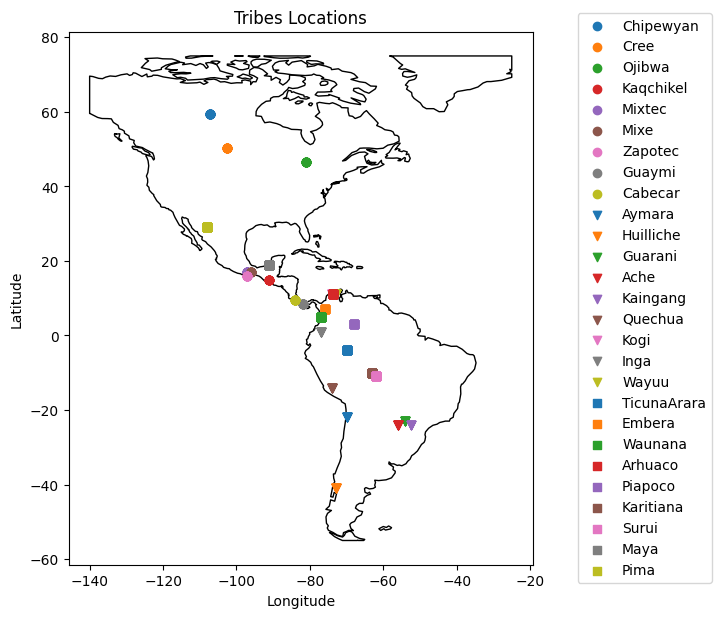

In [1]:

import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## Code Explanation

This code reads geographic data from `NAm2.txt` and plots the locations of different populations on a map of the Americas.

First, the dataset is loaded into a pandas DataFrame. Latitude and longitude values are extracted and converted into geographic points using GeoPandas, creating a `GeoDataFrame`.

Then, a land map from the Natural Earth dataset is used as a background. The map is clipped to the region of interest, corresponding roughly to the Americas.

Each population in the `Pop` column is plotted separately with a different color and marker, allowing visual comparison of their spatial distribution.


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
# longitude
y = df.iloc[:, 7].to_numpy()

# genetic markers
X = df.iloc[:, 8:].to_numpy()

# This fails because X.T @ X is singular: rank(X) < p since p = 5709 > N = 494
beta_hat = np.linalg.solve(X.T @ X, X.T @ y)

LinAlgError: Singular matrix

The error occurs because the classical normal-equation approach requires the matrix $$(X^\top X)$$ to be invertible. Here, the number of genetic markers is much larger than the number of samples, so the predictor matrix is rank-deficient. Hence, $$(X^\top X)$$ is singular, and the coefficients of the standard multiple linear regression model cannot be estimated uniquely.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [3]:
beta_hat = np.linalg.lstsq(X, y)[0]
beta_hat

array([-0.04005781, -0.01940898,  0.01111306, ..., -0.21729626,
       -0.10210421,  0.01813644], shape=(5709,))

### Estimation with `numpy.linalg.lstsq`

Using `numpy.linalg.lstsq`, no error is obtained.

This is because `numpy.linalg.solve` is used to solve an exact linear system and requires the matrix to be square and invertible. In part (a), we applied it to $$X^\top X$$, but this matrix is singular because $$\mathrm{rank}(X) < p$$.

In contrast, `numpy.linalg.lstsq` computes a least-squares solution to

$$
\min_{\beta} \|y - X\beta\|_2^2
$$

and it can handle rank-deficient matrices. Therefore, even though the regression coefficients are not uniquely determined, `lstsq` is still able to return one valid solution.

Here, since

$$
p > N
$$

the matrix $$X$$ cannot have full column rank, which explains why `solve` fails but `lstsq` works.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [4]:
from sklearn.linear_model import LinearRegression
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression(fit_intercept=True)
lr.fit(X, y)
print("Coefficients:", lr.coef_)
print("beta_hat", beta_hat)

Coefficients: [-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]
beta_hat [-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


### (c)

Using `LinearRegression`, no error is obtained. This is expected because `sklearn` fits ordinary least squares using a least-squares solver rather than solving $$X^\top X \beta = X^\top y$$ with an exact inverse, so it can handle rank-deficient matrices. :contentReference[oaicite:0]{index=0}

The coefficients in `lr.coef_` are usually not exactly the same as in part (b), because `sklearn` centers the data when `fit_intercept=True`. In its preprocessing step, it centers both $$X$$ and $$y$$, and then reconstructs the intercept afterward.

A practical reason for this re-centering is that the intercept becomes easier to interpret: it corresponds to the predicted value when the predictors are at their average level. It also improves numerical stability when fitting the model.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

### (a) Main ideas of PCA

Principal Component Analysis (PCA) is a dimension-reduction method that transforms a set of possibly correlated variables into a new set of orthogonal variables called **principal components**.

From a **geometric point of view**, PCA finds new axes in the feature space such that:
- the first principal component is the direction along which the data vary the most,
- the second principal component is orthogonal to the first one and explains the largest remaining variability,
- and so on.

So PCA can be seen as a rotation of the coordinate system that aligns the axes with the main directions of the data cloud.

From a **statistical point of view**, PCA constructs linear combinations of the original variables that maximize the variance. The first components contain most of the information in the data, while later components often correspond to noise or less important variation.

As a result, PCA is often used to summarize high-dimensional data with only a few components, while keeping most of the variability of the original dataset.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

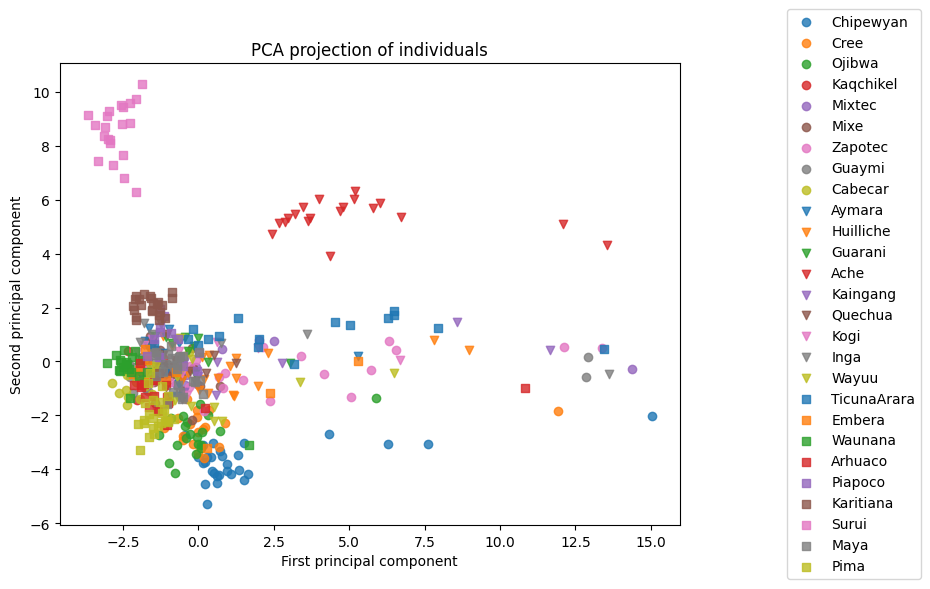

Explained variance ratio: [0.02050031 0.01518413]


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



# Select only the genetic markers
predictors = df.columns[8:]
X = df[predictors].values

# PCA on the genetic markers
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))


for i, tribe in enumerate(tribes.unique()):
    mask = tribes == tribe
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe,
        alpha=0.8
    )

ax.set_title("PCA projection of individuals")
ax.set_xlabel("First principal component")
ax.set_ylabel("Second principal component")
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

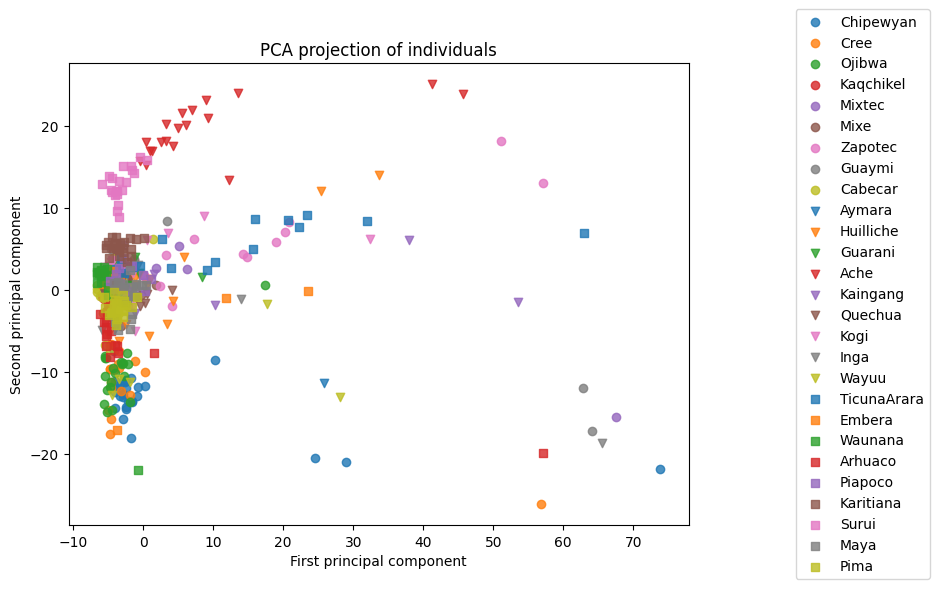

Explained variance ratio: [0.02367493 0.01025359]


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

# PCA on the genetic markers
pca = PCA(n_components=2)
X_std_pca = pca.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(8, 6))


for i, tribe in enumerate(tribes.unique()):
    mask = tribes == tribe
    ax.scatter(
        X_std_pca[mask, 0],
        X_std_pca[mask, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe,
        alpha=0.8
    )

ax.set_title("PCA projection of individuals")
ax.set_xlabel("First principal component")
ax.set_ylabel("Second principal component")
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

### (c)

The PCA plot obtained after standardization is clearly different from the previous one. In the first plot, most individuals are concentrated in a relatively compact region, while in the standardized version the points are much more spread out along both principal components.

This shows that scaling the markers changes the relative importance of the variables in the PCA. Without standardization, the principal components are more influenced by markers with larger variability. After standardization, all markers contribute more equally, which changes the directions of maximal variance.

In our case, the standardized PCA highlights stronger separation for some tribes and produces a wider dispersion of the observations. Therefore, the global structure of the data is not exactly the same as in the unscaled PCA.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

### (d)

For this dataset, standardization has a strong effect on the PCA representation, so it is not a neutral preprocessing step. The two plots are noticeably different, which shows that the scale of the variables influences the principal components.

Since all genetic markers are encoded in the same way (0/1), they are already measured on a common scale. Therefore, standardization is not strictly necessary here. In fact, applying it changes the relative importance of the markers by giving the same variance weight to all of them.

So, for this TP, it is reasonable to conclude that standardization is not essential, and that using the raw markers may be more natural. However, comparing both approaches remains useful because it shows how sensitive PCA can be to preprocessing.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [7]:
pct_2pc = 100 * np.sum(pca.explained_variance_ratio_[:2])
print(f"Percentage explained by the first two PCs: {pct_2pc:.2f}%")

Percentage explained by the first two PCs: 3.39%


Maximum number of PCs to plot: 494


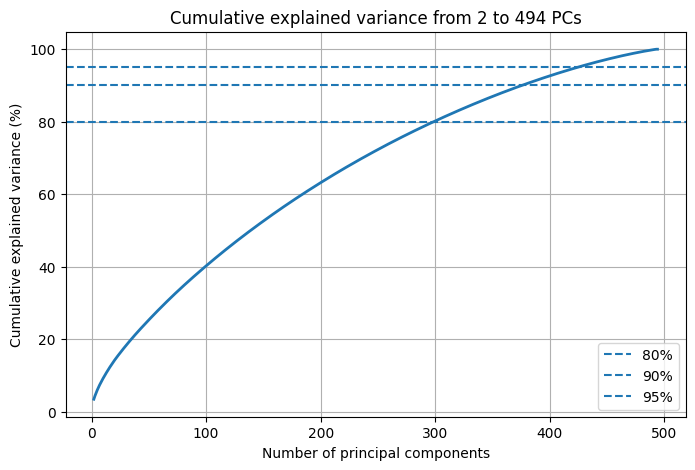

In [8]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Choose the data matrix
# Use X if you want the raw markers
# Use X_std if you want the standardized markers
X_data = X_std   # or X

# Full PCA
pca = PCA()
X_pca = pca.fit_transform(X_data)

# Cumulative explained variance in %
cum_var = 100 * np.cumsum(pca.explained_variance_ratio_)

# Maximum possible number of PCs
max_k = min(X_data.shape[0], X_data.shape[1])
print("Maximum number of PCs to plot:", max_k)

# Plot only from 2 PCs up to max_k PCs
k_values = np.arange(2, max_k + 1)

plt.figure(figsize=(8, 5))
plt.plot(k_values, cum_var[1:max_k], linewidth=2)
plt.axhline(80, linestyle="--", label="80%")
plt.axhline(90, linestyle="--", label="90%")
plt.axhline(95, linestyle="--", label="95%")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance (%)")
plt.title(f"Cumulative explained variance from 2 to {max_k} PCs")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
k80 = np.argmax(cum_var >= 80) + 1
k90 = np.argmax(cum_var >= 90) + 1
k95 = np.argmax(cum_var >= 95) + 1

print("PCs for 80%:", k80)
print("PCs for 90%:", k90)
print("PCs for 95%:", k95)

PCs for 80%: 299
PCs for 90%: 376
PCs for 95%: 425


### (e)

The cumulative explained variance plot shows that a large number of principal components is required to represent the genetic markers.

The first two principal components explain only a small proportion of the total variance. From the cumulative explained variance curve, we observe that:

- 299 principal components are needed to explain about 80\% of the variance,
- 376 principal components are needed to explain about 90\%,
- 425 principal components are needed to explain about 95\%.

Therefore, two principal components are clearly not sufficient to summarize the dataset. If we want to represent the genetic markers with a minimal number of principal components while preserving most of the information, a reasonable choice would be 376 components for a 90\% explained variance threshold.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

/tmp/ipykernel_187515/4039859812.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


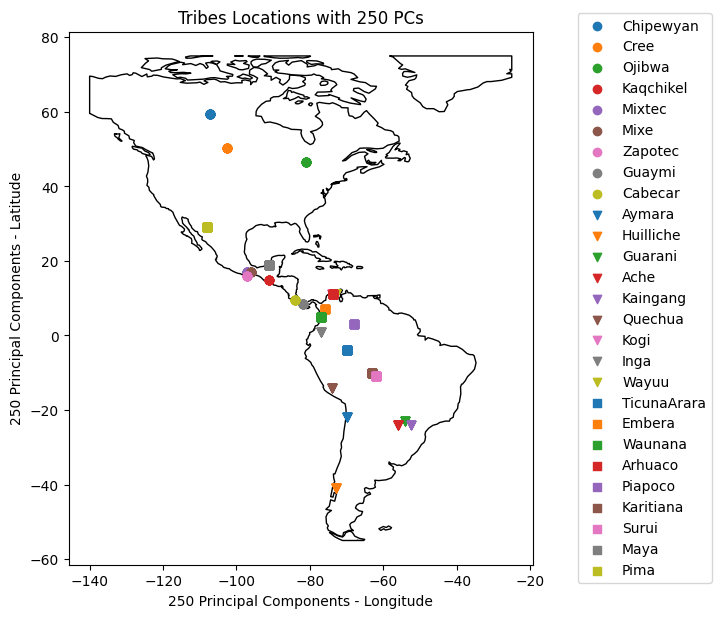

In [10]:




# PCA with the first 250 components
pca = PCA(n_components=250)
X_pca = pca.fit_transform(X_std)

# Linear regression for latitude
lr_lat = LinearRegression()
lr_lat.fit(X_pca, latitude)
lat_pred = lr_lat.predict(X_pca)

# Linear regression for longitude
lr_long = LinearRegression()
lr_long.fit(X_pca, longitude)
long_pred = lr_long.predict(X_pca)

# Store predictions
df_pred = df.copy()
df_pred["lat_pred"] = lat_pred
df_pred["long_pred"] = long_pred


# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df_pred, geometry=gpd.points_from_xy(long_pred, lat_pred))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations with 250 PCs')
ax.set_xlabel('250 Principal Components - Longitude')
ax.set_ylabel('250 Principal Components - Latitude')
fig.show()

### (a)

Using the scores of the first 250 principal components, the predicted map is almost identical to the observed map. This means that the model is able to reproduce the spatial coordinates of the individuals in the dataset very accurately.

This suggests that the genetic markers contain strong information about geographical origin. However, this result is **too optimistic** if we want to assess the ability of the method to predict the origin of individuals **outside the database**.

The reason is that the model is trained and evaluated on the same observations. Therefore, the predictions are in-sample predictions, and the model may partly overfit the data, especially since 250 principal components still represent a large number of predictors.

So, although the map shows that genetic markers are informative for geographic origin, it does not provide a realistic measure of performance on new unseen individuals. A train/test split or cross-validation would be needed to evaluate the true predictive ability of the model.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [11]:
from sklearn.metrics.pairwise import haversine_distances

# True and predicted coordinates in degrees
real_coords = df_pred[["lat", "long"]].to_numpy()
pred_coords = df_pred[["lat_pred", "long_pred"]].to_numpy()

# Convert to radians
real_coords_rad = np.radians(real_coords)
pred_coords_rad = np.radians(pred_coords)

# Pairwise haversine distance matrix, then keep the diagonal
# because we want distance between each point and its own prediction
dist_matrix = haversine_distances(real_coords_rad, pred_coords_rad)

# Convert angular distance to kilometers
earth_radius_km = 6371.0087714 
dist_km = np.diag(dist_matrix) * earth_radius_km

# Mean error in kilometers
mean_error_km = dist_km.mean()

print(f"Mean distance error: {mean_error_km:.2f} km")

Mean distance error: 519.44 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

### (a)

Cross-validation is a method used to estimate how well a model will perform on unseen data. In K-fold cross-validation, the data are split into K folds. The model is trained on K-1 folds and tested on the remaining one, and this is repeated K times.

It is useful because it gives a better estimate of prediction error than testing the model on the training data, and it helps choose model complexity, for example the number of principal components.

When the samples are not IID, standard random cross-validation may be misleading. In that case, adapted strategies should be used, such as grouped cross-validation, time-series cross-validation, or spatial cross-validation.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

### (b)

The most adequate choice here is **GroupKFold**, using the **country** of each individual as the grouping variable.

The reason is that individuals from the same country are likely not IID, so putting some of them in the training set and others in the validation set could give an overly optimistic error. `GroupKFold` avoids this by ensuring that the same group does not appear in both training and validation folds.

This is also preferable because the rows of the dataframe may be ordered by geographic origin or population. The scikit-learn documentation notes that plain `KFold` splits data into consecutive folds by default, without shuffling, so it can be problematic when the ordering is not arbitrary.

So, in this context, grouping by country with `GroupKFold` gives a more realistic evaluation of predictive performance.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [12]:

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline


# Targets: latitude and longitude together
y = df[["lat", "long"]].values

# Use the country column as grouping variable
# If your dataframe has an explicit country column name, you can replace this by df["Country"]
groups = df.iloc[:, 1].values

# 10-fold grouped cross-validation
cv = GroupKFold(n_splits=10)

# PCR pipeline with 4 principal components
pipe = make_pipeline(
    PCA(n_components=4),
    LinearRegression()
)

# Out-of-fold predictions
y_pred_oof = np.zeros_like(y, dtype=float)
fold_errors_km = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_std, y, groups=groups), start=1):
    X_train, X_test = X_std[train_idx], X_std[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    y_pred_oof[test_idx] = y_pred

    # Haversine distance for this fold
    dist_matrix = haversine_distances(
        np.radians(y_test),
        np.radians(y_pred)
    )
    dist_km = np.diag(dist_matrix) * earth_radius_km
    fold_mean_km = dist_km.mean()
    fold_errors_km.append(fold_mean_km)

    print(f"Fold {fold}: mean error = {fold_mean_km:.2f} km")

# Overall cross-validated error
dist_matrix_all = haversine_distances(
    np.radians(y),
    np.radians(y_pred_oof)
)
dist_km_all = np.diag(dist_matrix_all) * earth_radius_km

mean_error_km = dist_km_all.mean()
std_error_km = dist_km_all.std()

print(f"\nOverall mean CV error: {mean_error_km:.2f} km")
print(f"Overall std of pointwise errors: {std_error_km:.2f} km")
print(f"Mean of fold errors: {np.mean(fold_errors_km):.2f} km")

Fold 1: mean error = 3795.58 km
Fold 2: mean error = 2812.53 km
Fold 3: mean error = 1361.96 km
Fold 4: mean error = 1714.90 km
Fold 5: mean error = 2201.49 km
Fold 6: mean error = 3223.54 km
Fold 7: mean error = 2843.99 km
Fold 8: mean error = 2140.38 km
Fold 9: mean error = 1443.27 km
Fold 10: mean error = 2895.70 km

Overall mean CV error: 2460.92 km
Overall std of pointwise errors: 1575.96 km
Mean of fold errors: 2443.34 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [13]:
# Predictors: genetic markers
X = df.iloc[:, 8:].values

# Targets: latitude and longitude
y = df[["lat", "long"]].values

# Group variable: country
# Change this if your country column has another name
groups = df.iloc[:, 1].values

# 10-fold grouped cross-validation
cv = GroupKFold(n_splits=10)
cv_splits = list(cv.split(X, y, groups=groups))

earth_radius_km = 6371.0

def mean_haversine_km(y_true, y_pred):
    dist_matrix = haversine_distances(
        np.radians(y_true),
        np.radians(y_pred)
    )
    return np.diag(dist_matrix).mean() * earth_radius_km

n_components_grid = list(range(2, 441, 10))
if n_components_grid[-1] != 440:
    n_components_grid.append(440)

# Make sure all values are valid for every training fold
min_train_size = min(len(train_idx) for train_idx, _ in cv_splits)
max_valid_components = min(440, X.shape[1], min_train_size)
n_components_grid = [k for k in n_components_grid if k <= max_valid_components]

mean_train_errors = []
mean_test_errors = []

for n_comp in n_components_grid:
    fold_train_errors = []
    fold_test_errors = []

    pipe = make_pipeline(
        PCA(n_components=n_comp),
        LinearRegression()
    )

    for train_idx, test_idx in cv_splits:
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipe.fit(X_train, y_train)

        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        train_error_km = mean_haversine_km(y_train, y_train_pred)
        test_error_km = mean_haversine_km(y_test, y_test_pred)

        fold_train_errors.append(train_error_km)
        fold_test_errors.append(test_error_km)

    mean_train_errors.append(np.mean(fold_train_errors))
    mean_test_errors.append(np.mean(fold_test_errors))

# Best number of PCs according to test error
best_idx = np.argmin(mean_test_errors)
best_n_components = n_components_grid[best_idx]
best_test_error = mean_test_errors[best_idx]

print(f"Best number of PCs: {best_n_components}")
print(f"Best mean test error: {best_test_error:.2f} km")

Best number of PCs: 222
Best mean test error: 2041.17 km


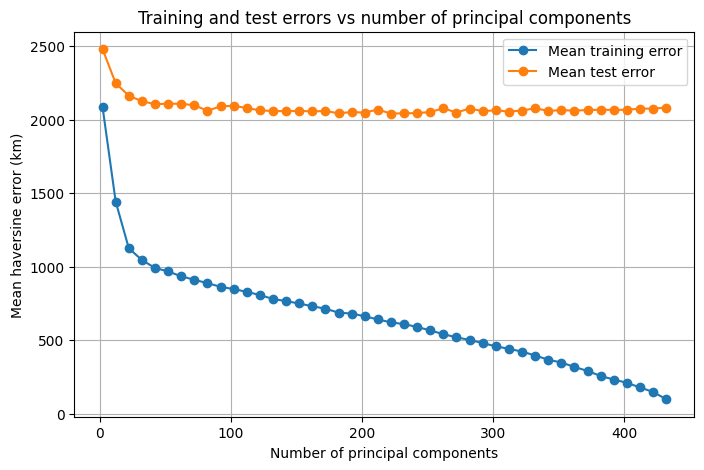

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(n_components_grid, mean_train_errors, marker="o", label="Mean training error")
plt.plot(n_components_grid, mean_test_errors, marker="o", label="Mean test error")
plt.xlabel("Number of principal components")
plt.ylabel("Mean haversine error (km)")
plt.title("Training and test errors vs number of principal components")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
print(f"Best number of PCs: {best_n_components}")
print(f"Best mean test error: {best_test_error:.2f} km")

Best number of PCs: 222
Best mean test error: 2041.17 km


**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.